# Lista de Exercícios 04
## Ajuste por Mínimos Quadrados

**Programa:** PPGMC / UESC  
**Base:** Burden & Faires — Capítulo 8  

---

## Objetivos

- consolidar o conceito de **mínimos quadrados**;
- comparar com **interpolação polinomial** e **splines**;
- analisar **resíduos e erro**;
- discutir **condicionamento e estabilidade numérica**.

---

## Conexão com listas anteriores

Esta lista retoma ideias de:

- Lista 2 (interpolação)
- Lista 3 (splines)

Agora com foco em **ajuste**.

## Exercício 1

Dados:
x = [0,1,2,3,4]  
y = [1.1,2.0,2.9,4.1,5.0]

Tarefas:
- ajustar reta
- plotar dados e ajuste
- calcular resíduos
- interpretar

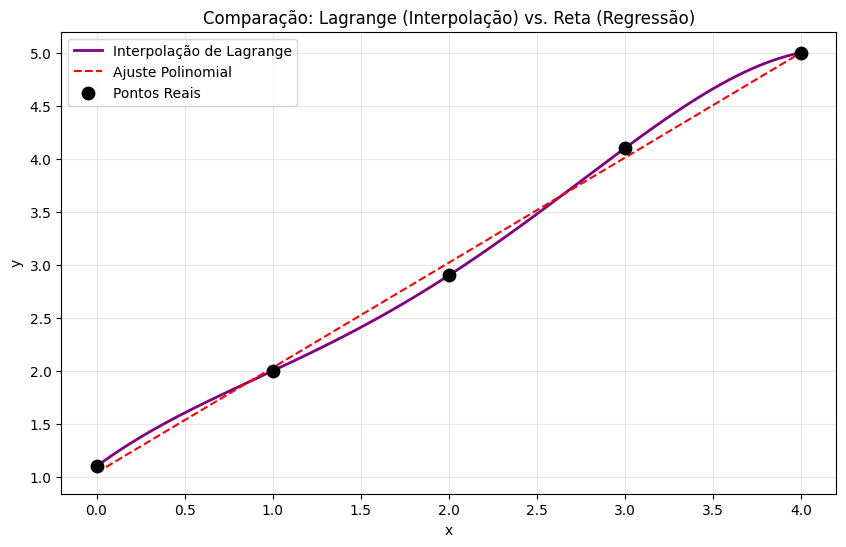

x     | y Real   | Ajuste          | Lagrange       


0     | 1.10     | 0.0600          | 0.0000         
1     | 2.00     | -0.0300         | 0.0000         
2     | 2.90     | -0.1200         | 0.0000         
3     | 4.10     | 0.0900          | 0.0000         
4     | 5.00     | 0.0000          | 0.0000         


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Função de interpolação de Lagrange
def lagrange(x_alvo,x,y):
    grau = len(x)
    soma = 0.0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if i != j:
                mult *= ((x_alvo - x[j]) / (x[i] - x[j]))
        soma += mult 
    return soma  

# Inicialização dos pontos
x = np.array([0, 1, 2, 3, 4])
y = np.array([1.1, 2.0, 2.9, 4.1, 5.0])

x_plot = np.linspace(min(x), max(x), 200)

# Cálculo do ajuste linear
coef_global = np.polyfit(x, y, 1)
p_global = np.poly1d(coef_global)
y_ajuste = p_global(x_plot)

# Cálculo de Lagrange
y_lagrange_plot = [lagrange(val, x, y) for val in x_plot]

plt.figure(figsize=(10, 6))

plt.plot(x_plot, y_lagrange_plot, color='purple', lw=2, label='Interpolação de Lagrange')

plt.plot(x_plot, y_ajuste, color='red', linestyle='--', label=f'Ajuste Polinomial')

plt.scatter(x, y, color='black', s=80, zorder=5, label='Pontos Reais')

plt.title('Comparação: Lagrange (Interpolação) vs. Reta (Regressão)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo dos resíduos
y_pred_reta = p_global(x)
y_pred_lagrange = np.array([lagrange(val, x, y) for val in x])

residuos_reta = y - y_pred_reta
residuos_lag = y - y_pred_lagrange

print(f"{'x':<5} | {'y Real':<8} | {'Ajuste':<15} | {'Lagrange':<15}")
print('\n')
for i in range(len(x)):
    print(f"{x[i]:<5} | {y[i]:<8.2f} | {residuos_reta[i]:<15.4f} | {residuos_lag[i]:<15.4f}")

O ajuste não teve um resultado tão bom quando a interpolação de lagrange, onde o método força o polinômio a passar exatamente em todos os pontos fornecidos. No entanto isso pode ser explicado pelo grau do ajuste ser muito baixo, o exemplo fornecido é um polinômio de grau 4, portanto um ajuste de primeiro grau não consegue demonstrar precisamente o comportamento desses pontos. Isso é mostrado no código abaixo, que compara o comportamento do ajuste com graus diferentes. 

## Exercício 2

Com os mesmos dados:

- ajuste graus 1,2,3
- compare graficamente
- compare erros
- discuta aumento de grau

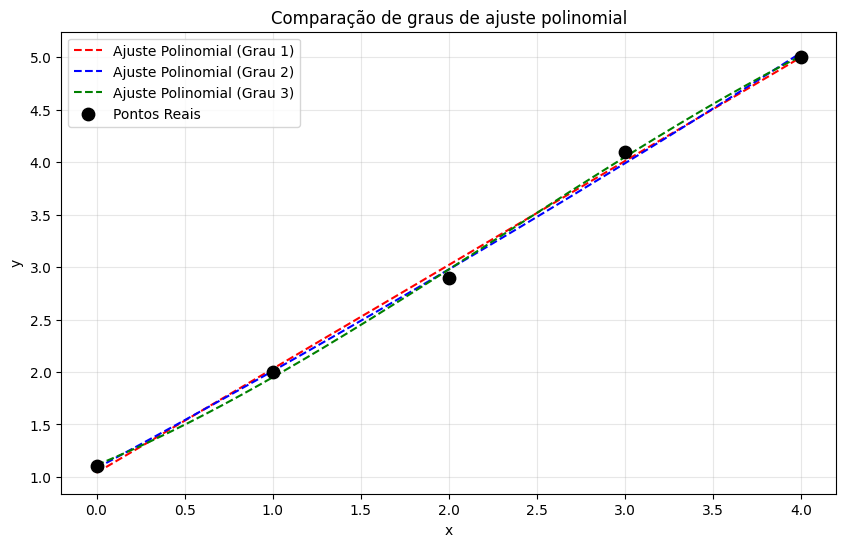

x     | y Real   | Grau 1          | Grau 2          | Grau 3         


0     | 1.10     | 0.0600          | 0.0171          | -0.0129        
1     | 2.00     | -0.0300         | -0.0086         | 0.0514         
2     | 2.90     | -0.1200         | -0.0771         | -0.0771        
3     | 4.10     | 0.0900          | 0.1114          | 0.0514         
4     | 5.00     | 0.0000          | -0.0429         | -0.0129        


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Inicialização dos pontos
x = np.array([0, 1, 2, 3, 4])
y = np.array([1.1, 2.0, 2.9, 4.1, 5.0])

x_plot = np.linspace(min(x), max(x), 200)

# Cálculo dos ajustes polinomiais de graus 1, 2 e 3
coef_1 = np.polyfit(x, y, 1)
p_1 = np.poly1d(coef_1)
y1 = p_1(x_plot)

coef_2 = np.polyfit(x, y, 2)
p_2 = np.poly1d(coef_2)
y2= p_2(x_plot)

coef_3 = np.polyfit(x, y, 3)
p_3 = np.poly1d(coef_3)
y3 = p_3(x_plot)

plt.figure(figsize=(10, 6))


plt.plot(x_plot, y1, color='red', linestyle='--', label=f'Ajuste Polinomial (Grau 1)')

plt.plot(x_plot, y2, color='blue', linestyle='--', label=f'Ajuste Polinomial (Grau 2)')

plt.plot(x_plot, y3, color='green', linestyle='--', label=f'Ajuste Polinomial (Grau 3)')

plt.scatter(x, y, color='black', s=80, zorder=5, label='Pontos Reais')

plt.title('Comparação de graus de ajuste polinomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

y1 = p_1(x)
y2 = p_2(x)
y3 = p_3(x)

# Cálculo dos resíduos
residuos_1 = y - y1
residuos_2 = y - y2
residuos_3 = y - y3

print(f"{'x':<5} | {'y Real':<8} | {'Grau 1':<15} | {'Grau 2':<15} | {'Grau 3':<15}")
print('\n')
for i in range(len(x)):
    print(f"{x[i]:<5} | {y[i]:<8.2f} | {residuos_1[i]:<15.4f} | {residuos_2[i]:<15.4f} | {residuos_3[i]:<15.4f}")

É possível ver que ao aumentar o grau conseguimos um resultado cada vez mais preciso, com o melhor resultado atualmente sendo com o grau três. No teste abaixo, explorei o comportamento do ajuste quando aumento o grau ainda mais. Conseguimos ver que os resíduos agora são sempre 0 e as três curvas geradas tem um comportamento extremamente semelhante com uma pequena instabilidade perto dos extremos.

/var/folders/qw/v1v41zkx3w53m8bcz3ng_tqw0000gn/T/ipykernel_7800/2367380515.py:15: RankWarning: Polyfit may be poorly conditioned
  coef_5 = np.polyfit(x, y, 5)
/var/folders/qw/v1v41zkx3w53m8bcz3ng_tqw0000gn/T/ipykernel_7800/2367380515.py:19: RankWarning: Polyfit may be poorly conditioned
  coef_6 = np.polyfit(x, y, 6)


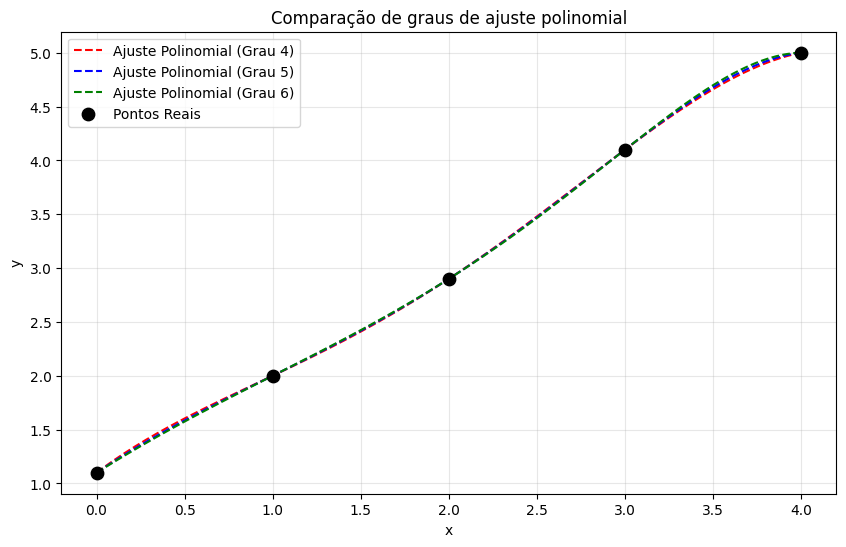

x     | y Real   | Grau 4          | Grau 5          | Grau 6         


0     | 1.10     | 0.0000          | 0.0000          | -0.0000        
1     | 2.00     | -0.0000         | 0.0000          | -0.0000        
2     | 2.90     | -0.0000         | 0.0000          | -0.0000        
3     | 4.10     | 0.0000          | 0.0000          | -0.0000        
4     | 5.00     | 0.0000          | -0.0000         | -0.0000        


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Inicialização dos pontos
x = np.array([0, 1, 2, 3, 4])
y = np.array([1.1, 2.0, 2.9, 4.1, 5.0])

x_plot = np.linspace(min(x), max(x), 200)

# Cálculo dos ajustes polinomiais de graus 4, 5 e 6
coef_4 = np.polyfit(x, y, 4)
p_4 = np.poly1d(coef_4)
y4 = p_4(x_plot)

coef_5 = np.polyfit(x, y, 5)
p_5 = np.poly1d(coef_5)
y5 = p_5(x_plot)

coef_6 = np.polyfit(x, y, 6)
p_6 = np.poly1d(coef_6)
y6 = p_6(x_plot)

plt.figure(figsize=(10, 6))


plt.plot(x_plot, y4, color='red', linestyle='--', label=f'Ajuste Polinomial (Grau 4)')

plt.plot(x_plot, y5, color='blue', linestyle='--', label=f'Ajuste Polinomial (Grau 5)')

plt.plot(x_plot, y6, color='green', linestyle='--', label=f'Ajuste Polinomial (Grau 6)')

plt.scatter(x, y, color='black', s=80, zorder=5, label='Pontos Reais')

plt.title('Comparação de graus de ajuste polinomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

y4 = p_4(x)
y5 = p_5(x)
y6 = p_6(x)

residuos_4 = y - y4
residuos_5 = y - y5
residuos_6 = y - y6

print(f"{'x':<5} | {'y Real':<8} | {'Grau 4':<15} | {'Grau 5':<15} | {'Grau 6':<15}")
print('\n')
for i in range(len(x)):
    print(f"{x[i]:<5} | {y[i]:<8.2f} | {residuos_4[i]:<15.4f} | {residuos_5[i]:<15.4f} | {residuos_6[i]:<15.4f}")

## Exercício 3 — Integrador

Função de Runge:

$f(x) = \frac{1}{(1+25x^2)}$

- gerar 10 pontos
- comparar:
  - interpolação
  - spline
  - mínimos quadrados (grau 3)
- analisar erro e estabilidade

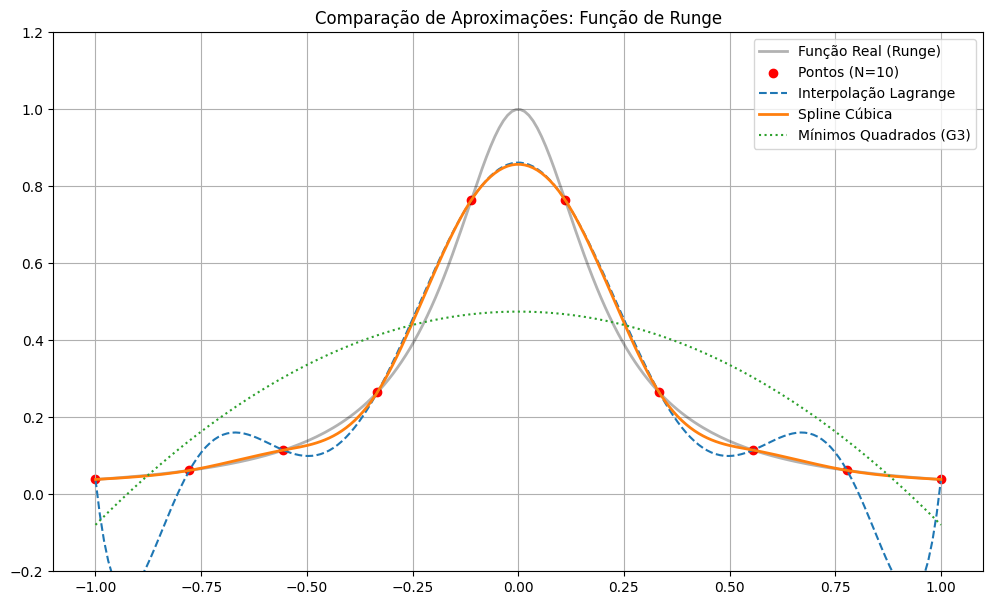

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Função de Runge
def runge(x):
    return 1 / (1 + 25*x**2)

# Implementação da interpolação de Lagrange
def lagrange(x_alvo,x,y):
    grau = len(x)
    soma = 0.0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if i != j:
                mult *= ((x_alvo - x[j]) / (x[i] - x[j]))
        soma += mult 
    return soma  

# Implementação da Spline Cúbica
def spline(x, y):
    n = len(x)
    h = np.zeros(n - 1)
    for i in range(n - 1):
        h[i] = x[i+1] - x[i]
    
    alpha = np.zeros(n - 1)
    for i in range(1, n - 1):
        alpha[i] = (3/h[i])*(y[i+1] - y[i]) - (3/h[i-1])*(y[i] - y[i-1])
    
    l = np.ones(n)
    mu = np.zeros(n)
    z = np.zeros(n)
    
    for i in range(1, n - 1):
        l[i] = 2*(x[i+1] - x[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i]/l[i]
        z[i] = (alpha[i] - h[i-1]*z[i-1])/l[i]
    
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)
    
    for j in range(n-2, -1, -1):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j])/h[j] - (h[j]*(c[j+1] + 2*c[j]))/3
        d[j] = (c[j+1] - c[j])/(3*h[j])
        
    return b[:-1], c[:-1], d[:-1]

# Inicialização dos dados
x_dados = np.linspace(-1, 1, 10)
y_dados = runge(x_dados)

x_ref = np.linspace(-1, 1, 200)
y_real = runge(x_ref)

# Calculo das aproximações por Lagrange
y_lagrange = [lagrange(val, x_dados, y_dados) for val in x_ref]

# Calculo das aproximações por Spline Cúbica
b, c, d = spline(x_dados, y_dados)
y_spline = []

for val in x_ref:
    # Encontrar o índice do intervalo correto para o ponto 'val'
    idx = 0
    for i in range(len(x_dados) - 1):
        if val >= x_dados[i] and val <= x_dados[i+1]:
            idx = i
            break
    
    # Aplicar a fórmula da sua função: S_i(x) = y_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3
    dx = val - x_dados[idx]
    val_interpolado = y_dados[idx] + b[idx]*dx + c[idx]*(dx**2) + d[idx]*(dx**3)
    y_spline.append(val_interpolado)

# C. Mínimos Quadrados (Grau 3)
coefs_mq = np.polyfit(x_dados, y_dados, 3)
y_mq = np.polyval(coefs_mq, x_ref)

# 2. Visualização
plt.figure(figsize=(12, 7))
plt.plot(x_ref, y_real, 'k', lw=2, label='Função Real (Runge)', alpha=0.3)
plt.scatter(x_dados, y_dados, color='red', label='Pontos (N=10)')

plt.plot(x_ref, y_lagrange, label='Interpolação Lagrange', ls='--')
plt.plot(x_ref, y_spline, label='Spline Cúbica', lw=2)
plt.plot(x_ref, y_mq, label='Mínimos Quadrados (G3)', ls=':')

plt.ylim(-0.2, 1.2)
plt.title('Comparação de Aproximações: Função de Runge')
plt.legend()
plt.grid(True)
plt.show()

Novamente é possível ver que o ajuste teve o pior resultado, sendo o mais impreciso o que se dá pelo grau do ajuste. No entanto ao aumentar o grau, como visto no teste realizado na célula abaixo, podemos ver um aumento na instabilidade nos extremos. A mesma instabilidade pode ser vista na interpolação de Lagrange, onde o meio comsegui acompanhar o spline cúbico mas os extremos mostram muita instabilidade. Entre as três aproximações o melhor veio do spline cúbico, sendo o mais preciso e menos instável. 

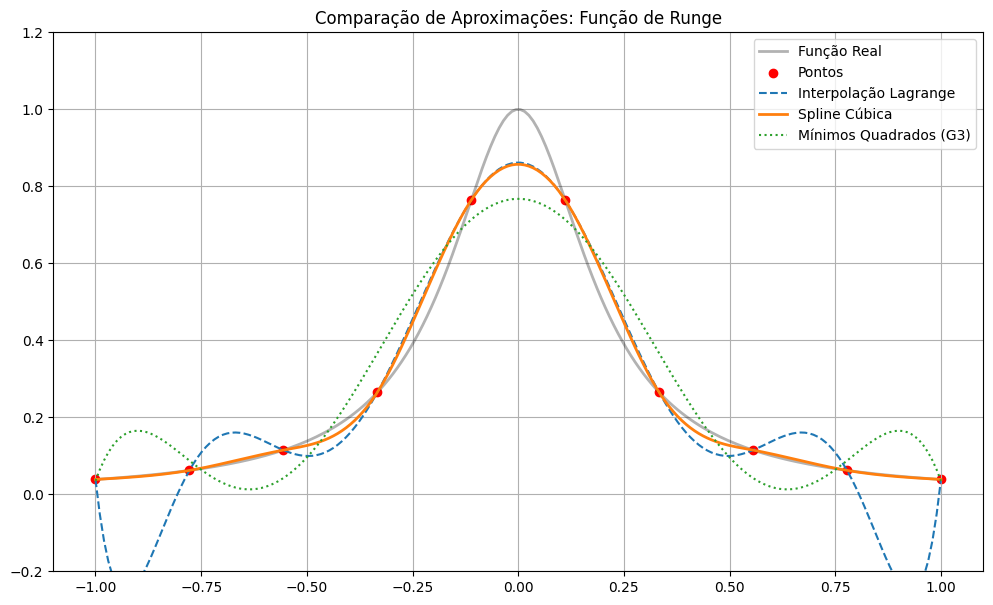

In [5]:
# Sua solução aqui
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


def runge(x):
    return 1 / (1 + 25*x**2)


def lagrange(x_alvo,x,y):
    grau = len(x)
    soma = 0.0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if i != j:
                mult *= ((x_alvo - x[j]) / (x[i] - x[j]))
        soma += mult 
    return soma  

def spline(x, y):
    n = len(x)
    h = np.zeros(n - 1)
    for i in range(n - 1):
        h[i] = x[i+1] - x[i]
    
    alpha = np.zeros(n - 1)
    for i in range(1, n - 1):
        alpha[i] = (3/h[i])*(y[i+1] - y[i]) - (3/h[i-1])*(y[i] - y[i-1])
    
    l = np.ones(n)
    mu = np.zeros(n)
    z = np.zeros(n)
    
    for i in range(1, n - 1):
        l[i] = 2*(x[i+1] - x[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i]/l[i]
        z[i] = (alpha[i] - h[i-1]*z[i-1])/l[i]
    
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)
    
    for j in range(n-2, -1, -1):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j])/h[j] - (h[j]*(c[j+1] + 2*c[j]))/3
        d[j] = (c[j+1] - c[j])/(3*h[j])
        
    return b[:-1], c[:-1], d[:-1]

# Inicialização dos dados
x_dados = np.linspace(-1, 1, 10)
y_dados = runge(x_dados)

x_ref = np.linspace(-1, 1, 200)
y_real = runge(x_ref)

# Calculo Lagrange
y_lagrange = [lagrange(val, x_dados, y_dados) for val in x_ref]

# Calculo Spline Cúbica
b, c, d = spline(x_dados, y_dados)
y_spline = []

for val in x_ref:
    idx = 0
    for i in range(len(x_dados) - 1):
        if val >= x_dados[i] and val <= x_dados[i+1]:
            idx = i
            break
    
    dx = val - x_dados[idx]
    val_interpolado = y_dados[idx] + b[idx]*dx + c[idx]*(dx**2) + d[idx]*(dx**3)
    y_spline.append(val_interpolado)

# Calculo Mínimos Quadrados
coefs_mq = np.polyfit(x_dados, y_dados, 6)
y_mq = np.polyval(coefs_mq, x_ref)

# Plotagem
plt.figure(figsize=(12, 7))
plt.plot(x_ref, y_real, 'k', lw=2, label='Função Real', alpha=0.3)
plt.scatter(x_dados, y_dados, color='red', label='Pontos')

plt.plot(x_ref, y_lagrange, label='Interpolação Lagrange', ls='--')
plt.plot(x_ref, y_spline, label='Spline Cúbica', lw=2)
plt.plot(x_ref, y_mq, label='Mínimos Quadrados (G3)', ls=':')

plt.ylim(-0.2, 1.2)
plt.title('Comparação de Aproximações: Função de Runge')
plt.legend()
plt.grid(True)
plt.show()

## Exercício 4 — Avançado (Condicionamento)

- construir Vandermonde
- calcular cond(A)
- ajustar polinômios para y=exp(x)
- comparar normal vs lstsq
- discutir estabilidade

Grau   | Cond(A)    | Erro Normal     | Erro Lstsq     
-------------------------------------------------------
2      | 1.60e+01   | 9.38e-02        | 9.38e-02       
4      | 5.35e+02   | 1.13e-03        | 1.13e-03       
8      | 2.62e+06   | 5.25e-09        | 5.25e-09       
16     | 3.35e+07   | 1.47e-09        | 2.94e-12       


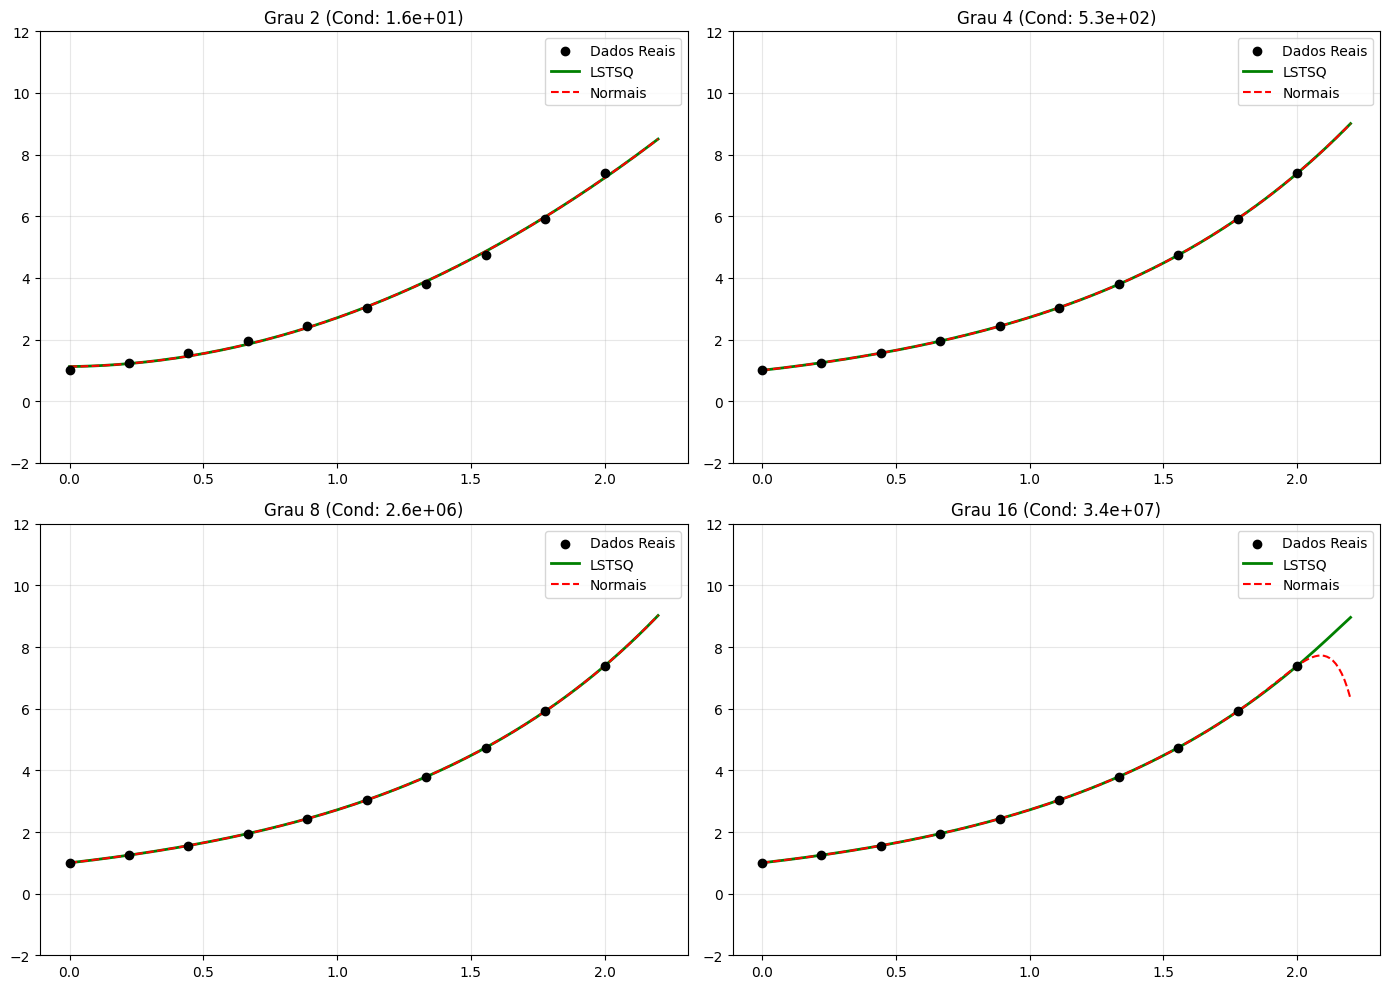

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Implementação de Vandermonde
def vandermonde(x, grau):
    n = len(x)
    V = np.zeros((n, grau + 1))
    for j in range(grau + 1):
        V[:, j] = x**(grau - j)
    return V

# Inicialização dos dados
n_pontos = 10
x = np.linspace(0, 2, n_pontos)
y = np.exp(x)
graus = [2, 4, 8, 16] 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print(f"{'Grau':<6} | {'Cond(A)':<10} | {'Erro Normal':<15} | {'Erro Lstsq':<15}")
print("-" * 55)

for i, grau in enumerate(graus):
    # Construir Vandermonde
    A = vandermonde(x, grau)
    cond_A = np.linalg.cond(A)
    
    # Método das Equações Normais
    try:
        c_normal = np.linalg.solve(A.T @ A, A.T @ y)
        y_normal_fit = A @ c_normal
        erro_normal = np.sqrt(np.mean((y - y_normal_fit)**2))
    except np.linalg.LinAlgError:
        erro_normal = np.inf
        c_normal = None
        
    # Método lstsq
    c_lstsq, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    y_lstsq_fit = A @ c_lstsq
    erro_lstsq = np.sqrt(np.mean((y - y_lstsq_fit)**2))
    
    print(f"{grau:<6} | {cond_A:<10.2e} | {erro_normal:<15.2e} | {erro_lstsq:<15.2e}")
    
    # Plotagem
    x_suave = np.linspace(0, 2.2, 200)
    A_suave = vandermonde(x_suave, grau)
    
    axes[i].scatter(x, y, color='black', label='Dados Reais', zorder=5)
    
    axes[i].plot(x_suave, A_suave @ c_lstsq, 'g-', label='LSTSQ', linewidth=2)
    
    if c_normal is not None:
        y_plot_normal = A_suave @ c_normal
        if np.max(np.abs(y_plot_normal)) < 500: 
            axes[i].plot(x_suave, y_plot_normal, 'r--', label='Normais')
    
    axes[i].set_title(f"Grau {grau} (Cond: {cond_A:.1e})")
    axes[i].set_ylim(-2, 12) 
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

O exercício demonstra a importância de saber quando o grau do ajuste tem que parar de aumentar, como visto no teste com grau 16 onde a implementação normal do ajuste por mínimos quadrados apresenta instabilidade no extremo superior enquanto o lstsq se manteve estável. O condicionamento também está crescendo com o aumento do grau.